# VisionInspect AI: System and Dataset Overview

**Purpose.** Establish the exact AI/ML problem, verify the complete 15-category MVTec AD dataset, and connect the data layout to the production inference pipeline.

**Expected result.** A dataset health table, class distribution, and real product examples for every supported category.

**Platform connection.** The category chosen during an inspection selects a category-specific detector profile, threshold, subtype classifier, and severity policy.

## End-to-end ML contract

```text
Product image + category
    -> image validation and preprocessing
    -> category-specific anomaly detection
    -> Good / Defective decision
    -> anomaly map, binary mask, and heatmap
    -> defect subtype classification (defective images only)
    -> defect geometry and explainability
    -> weighted severity score
    -> Pass / Review / Fail decision
    -> structured result for the FastAPI backend
```

MVTec AD is used as an anomaly-detection benchmark. Each category trains its anomaly model on normal images only; labelled test folders and masks are used for evaluation, threshold calibration, localization analysis, and subtype-classifier development.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from ml.model_registry import SUPPORTED_CATEGORIES

rows = []
for category in SUPPORTED_CATEGORIES:
    root = DATASET_ROOT / category
    train_good = image_files(root / "train" / "good")
    test_good = image_files(root / "test" / "good")
    defect_dirs = sorted(path for path in (root / "test").iterdir() if path.is_dir() and path.name != "good")
    defect_images = [(directory.name, path) for directory in defect_dirs for path in image_files(directory)]
    expected_masks = [mask_path_for(category, label, path) for label, path in defect_images]
    available_masks = sum(path is not None for path in expected_masks)
    sample_path = (train_good or test_good or [item[1] for item in defect_images])[0]
    sample = cv2.imread(str(sample_path), cv2.IMREAD_UNCHANGED)
    channels = 1 if sample.ndim == 2 else sample.shape[2]
    rows.append(
        {
            "category": category,
            "train_good": len(train_good),
            "test_good": len(test_good),
            "defect_images": len(defect_images),
            "defect_types": len(defect_dirs),
            "masks_found": available_masks,
            "missing_masks": len(defect_images) - available_masks,
            "sample_size": f"{sample.shape[1]} x {sample.shape[0]}",
            "channels": channels,
        }
    )

dataset_df = pd.DataFrame(rows)
display(dataset_df)
print(f"Categories verified: {len(dataset_df)} / {len(SUPPORTED_CATEGORIES)}")
print(f"Normal training images: {dataset_df['train_good'].sum():,}")
print(f"Test images: {(dataset_df['test_good'] + dataset_df['defect_images']).sum():,}")
print(f"Missing expected ground-truth masks: {dataset_df['missing_masks'].sum()}")

,category,train_good,test_good,defect_images,defect_types,masks_found,missing_masks,sample_size,channels
0,bottle,209,20,63,3,63,0,900 x 900,3
1,cable,224,58,92,8,92,0,1024 x 1024,3
2,capsule,219,23,109,5,109,0,1000 x 1000,3
3,carpet,280,28,89,5,89,0,1024 x 1024,3
4,grid,264,21,57,5,57,0,1024 x 1024,1
5,hazelnut,391,40,70,4,70,0,1024 x 1024,3
6,leather,245,32,92,5,92,0,1024 x 1024,3
7,metal_nut,220,22,93,4,93,0,700 x 700,3
8,pill,267,26,141,7,141,0,800 x 800,3
9,screw,320,41,119,5,119,0,1024 x 1024,1


Categories verified: 15 / 15
Normal training images: 3,629
Test images: 1,725
Missing expected ground-truth masks: 0


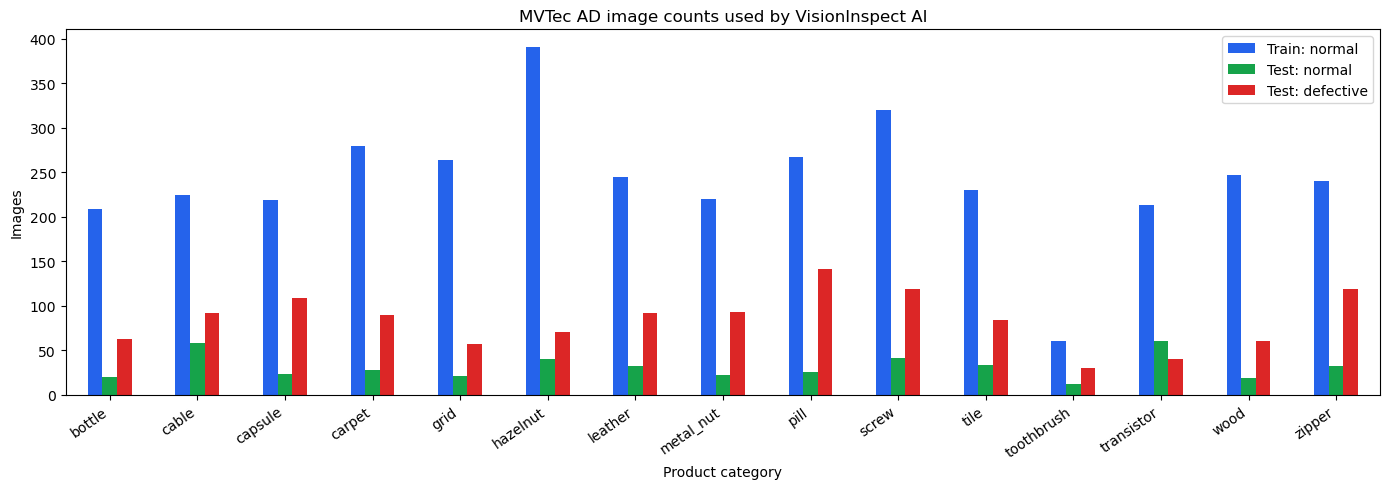

In [3]:
plot_df = dataset_df.set_index("category")[["train_good", "test_good", "defect_images"]]
ax = plot_df.plot(kind="bar", figsize=(14, 5), color=["#2563eb", "#16a34a", "#dc2626"])
ax.set_title("MVTec AD image counts used by VisionInspect AI")
ax.set_ylabel("Images")
ax.set_xlabel("Product category")
ax.legend(["Train: normal", "Test: normal", "Test: defective"])
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

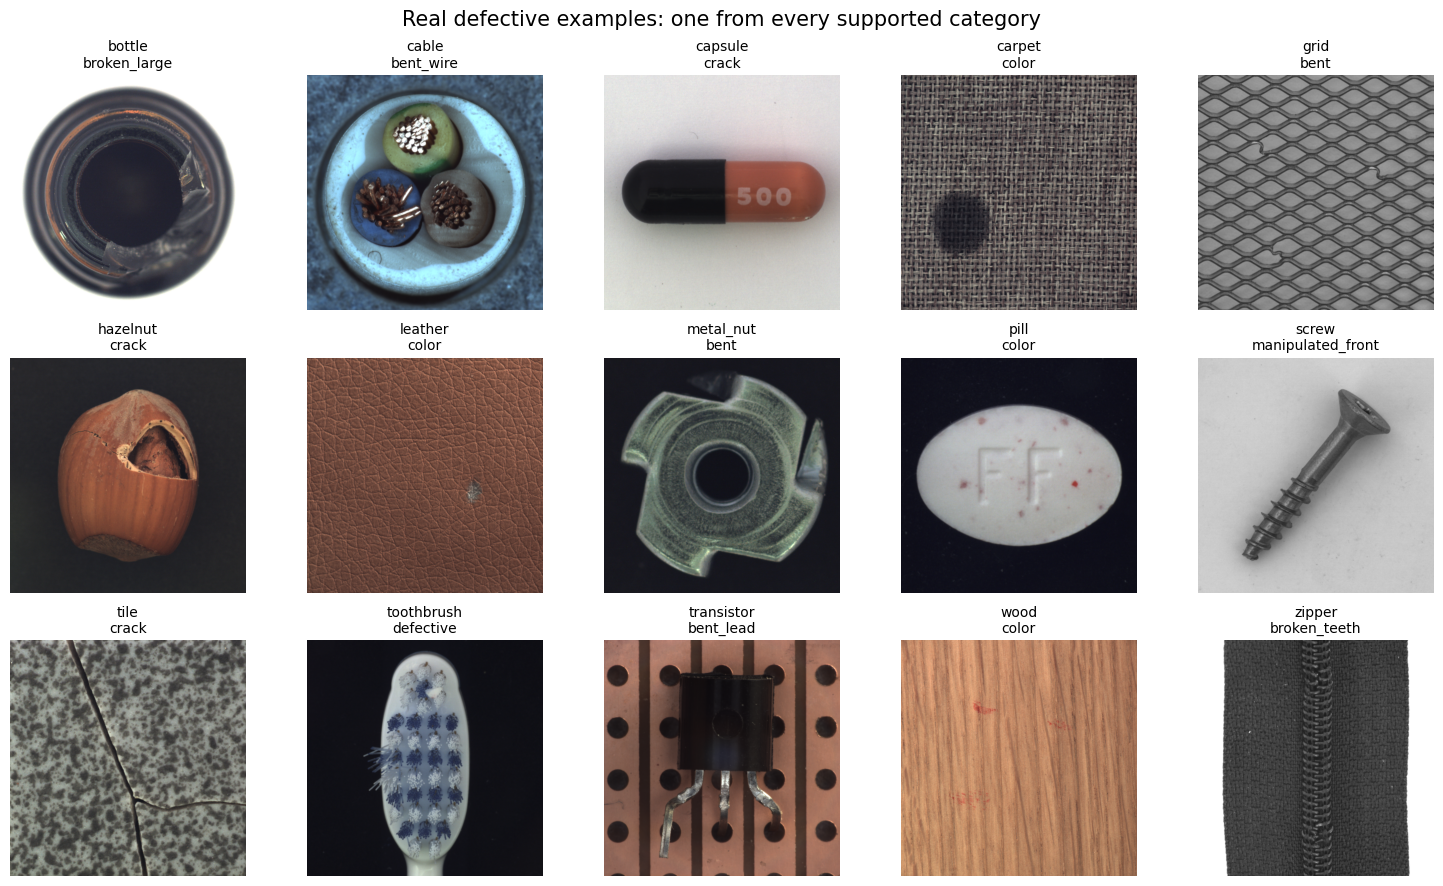

,category,defect_type,file
0,bottle,broken_large,000.png
1,cable,bent_wire,000.png
2,capsule,crack,000.png
3,carpet,color,000.png
4,grid,bent,000.png
5,hazelnut,crack,000.png
6,leather,color,000.png
7,metal_nut,bent,000.png
8,pill,color,000.png
9,screw,manipulated_front,000.png


In [4]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_rows = []
for axis, category in zip(axes.flat, SUPPORTED_CATEGORIES, strict=True):
    label, path = first_defect(category)
    image = read_rgb(path)
    axis.imshow(image)
    axis.set_title(f"{category}\n{label}", fontsize=10)
    axis.axis("off")
    sample_rows.append({"category": category, "defect_type": label, "file": path.name})
plt.suptitle("Real defective examples: one from every supported category", fontsize=15)
plt.tight_layout()
plt.show()
display(pd.DataFrame(sample_rows))

## What this demonstrates

- All 15 supported categories are read from the real MVTec AD directory.
- Training data contains normal samples; test data contains both normal and defective samples.
- Ground-truth masks provide pixel-level localization evidence for defective test images.
- The product category is part of the model input contract because each category has different appearance, defects, thresholds, and classifier labels.